In [306]:
import sys
import sklearn
import xgboost
import imblearn
import pandas
import numpy

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("pandas:", pandas.__version__)
print("NumPy:", numpy.__version__)

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.7.2
XGBoost: 3.2.0
imbalanced-learn: 0.14.0
pandas: 2.3.3
NumPy: 2.3.5


In [307]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [308]:
df = pd.read_csv(r"D:\vivian\ai4i2020.csv")

In [309]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [310]:
df_processed = df.copy()
df_processed = df_processed.drop(columns=["UDI", "Product ID"])

In [311]:
print("shape:", df.shape)

df.info()

shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: f

In [312]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [313]:
print("duplicate rows:", df.duplicated().sum())

duplicate rows: 0


In [314]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [315]:
df.describe(include="object")

,Product ID,Type
count,10000,10000
unique,10000,3
top,M14860,L
freq,1,6000


In [316]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [317]:
failure_counts = df["Machine failure"].value_counts()

failure_counts

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [318]:
failure_percentage = (
    df["Machine failure"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

failure_percentage

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

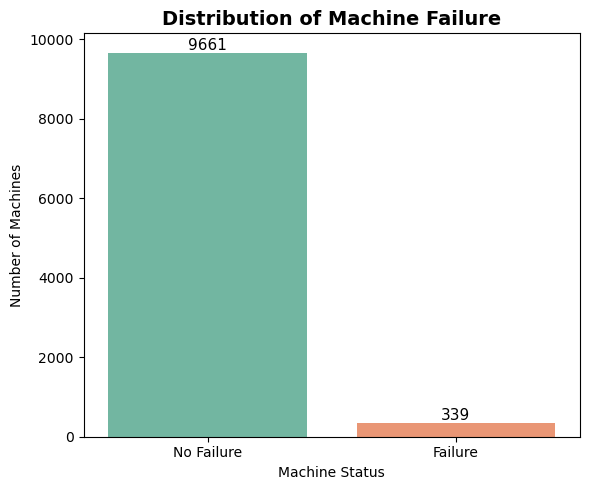

In [319]:
plt.figure(figsize=(6, 5))

ax = sns.countplot(
    data=df,
    x="Machine failure",
    hue="Machine failure",
    palette="Set2",
    legend=False
)

# Replace tick labels
ax.set_xticks([0, 1])
2
ax.set_xticklabels(["No Failure", "Failure"])

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Distribution of Machine Failure", fontsize=14, fontweight="bold")
plt.xlabel("Machine Status")
plt.ylabel("Number of Machines")

plt.tight_layout()
plt.show()


In [320]:
failure_counts = df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()
failure_counts

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [321]:
failure_summary = (
    failure_counts
    .reset_index()
)
failure_summary.columns = ["Failure Type", "Count"]

failure_summary

,Failure Type,Count
0,TWF,46
1,HDF,115
2,PWF,95
3,OSF,98
4,RNF,19


In [322]:
# Total number of recorded failure events
failure_summary["Count"].sum()

np.int64(373)

In [323]:
df["Machine failure"].sum()

np.int64(339)

In [324]:
# Number of failure mechanism recorded for each obsevation
failure_mechanisms = df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1)

failure_mechanisms.value_counts().sort_index()

0    9652
1     324
2      23
3       1
Name: count, dtype: int64

In [325]:
# compare Machine failure with the failure mechanisms

comparison = pd.DataFrame({
    "Machine failure": df["Machine failure"],
    "Failure mechanisms": df[[ "TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1)
})

comparison.head()

,Machine failure,Failure mechanisms
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [326]:
comparison[
    (comparison["Machine failure"] == 1) &
    (comparison["Failure mechanisms"] == 0)
]

,Machine failure,Failure mechanisms
1437,1,0
2749,1,0
4044,1,0
4684,1,0
5536,1,0
5941,1,0
6478,1,0
8506,1,0
9015,1,0


In [327]:
# Display the nine observations
df.loc[
    [1437, 2749, 4044, 4684, 5536, 5941, 6478, 8506, 9015],
    ["Type",
     "Air temperature [K]",
     "Process temperature [K]",
     "Rotational speed [rpm]",
     "Torque [Nm]",
     "Tool wear [min]",
     "Machine failure",
     "TWF",
     "HDF",
     "PWF",
     "OSF",
     "RNF"]
]

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1437,H,298.8,309.9,1439,45.2,40,1,0,0,0,0,0
2749,M,299.7,309.2,1685,28.9,179,1,0,0,0,0,0
4044,M,301.9,310.9,1419,47.7,20,1,0,0,0,0,0
4684,M,303.6,311.8,1421,44.8,101,1,0,0,0,0,0
5536,M,302.3,311.8,1363,54.0,119,1,0,0,0,0,0
5941,L,300.6,310.7,1438,48.5,78,1,0,0,0,0,0
6478,L,300.5,309.8,1663,29.1,145,1,0,0,0,0,0
8506,L,298.4,309.6,1710,27.3,163,1,0,0,0,0,0
9015,L,297.2,308.1,1431,49.7,210,1,0,0,0,0,0


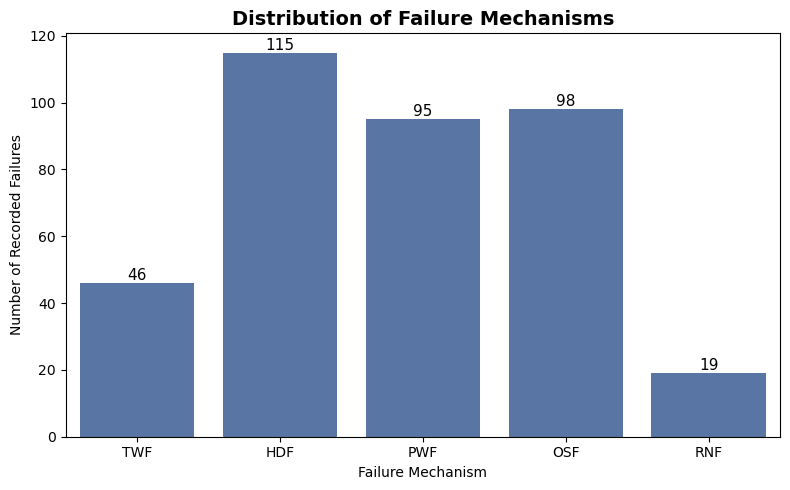

In [328]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=failure_summary,
    x="Failure Type",
    y="Count",
    color="#4C72B0"
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
)

plt.title(
    "Distribution of Failure Mechanisms",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Failure Mechanism")
plt.ylabel("Number of Recorded Failures")

plt.tight_layout()

plt.show()


In [329]:
# Count the number of machines in each category

machine_type_counts = df["Type"].value_counts()

machine_type_counts

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [330]:
machine_type_percentage = (
    df["Type"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

machine_type_percentage

Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64

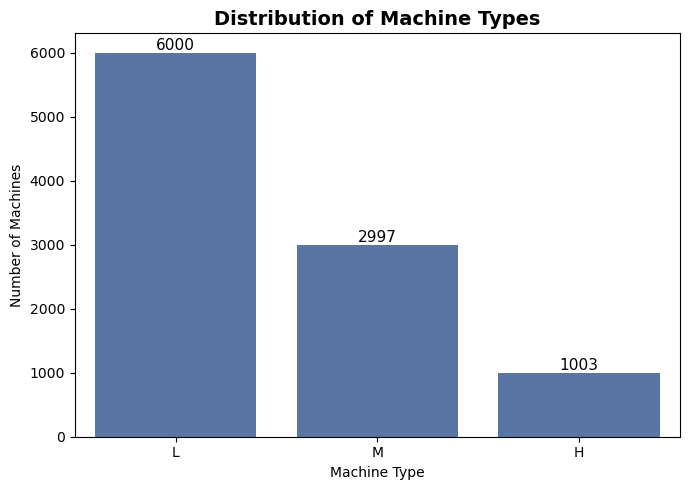

In [331]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Type",
    order=["L", "M", "H"],
    color="#4C72B0"
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Distribution of Machine Types", fontsize=14, fontweight="bold")
plt.xlabel("Machine Type")
plt.ylabel("Number of Machines")

plt.tight_layout()
plt.show()

In [332]:
# Cross-tabulation of machine type and machine failure
machine_failure_by_type = pd.crosstab(
    df["Type"],
    df["Machine failure"]
)

machine_failure_by_type

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [333]:
machine_failure_rate = (
    pd.crosstab(
        df["Type"],
        df["Machine failure"],
        normalize="index"
    ) * 100
).round(2)

machine_failure_rate

Machine failure,0,1
Type,,
H,97.91,2.09
L,96.08,3.92
M,97.23,2.77


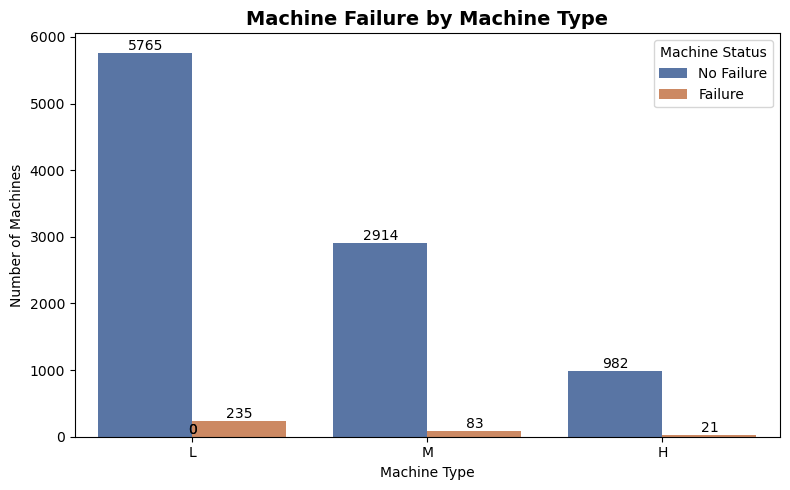

In [334]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Type",
    hue="Machine failure",
    order=["L", "M", "H"],
    palette=["#4C72B0", "#DD8452"]
)

# Add labels above each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width()/2, height),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Machine Failure by Machine Type", fontsize=14, fontweight="bold")
plt.xlabel("Machine Type")
plt.ylabel("Number of Machines")

# Improve legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["No Failure", "Failure"], title="Machine Status")

plt.tight_layout()
plt.show()

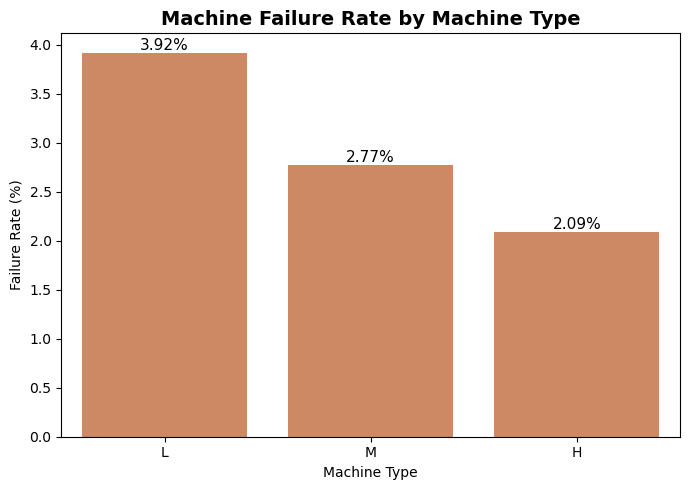

In [335]:
plt.figure(figsize=(7,5))

failure_rate = machine_failure_rate.loc[["L", "M", "H"], 1]

ax = sns.barplot(
    x=failure_rate.index,
    y=failure_rate.values,
    color="#DD8452"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title(
    "Machine Failure Rate by Machine Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Machine Type")
plt.ylabel("Failure Rate (%)")

plt.tight_layout()

plt.show()

In [336]:
def plot_boxplot(feature):
    plt.figure(figsize=(7,5))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature
    )

    plt.xticks([0, 1], ["No Failure", "Failure"])
    plt.title(f"{feature} by Machine Failure", fontsize=14, fontweight="bold")
    plt.xlabel("Machine Status")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

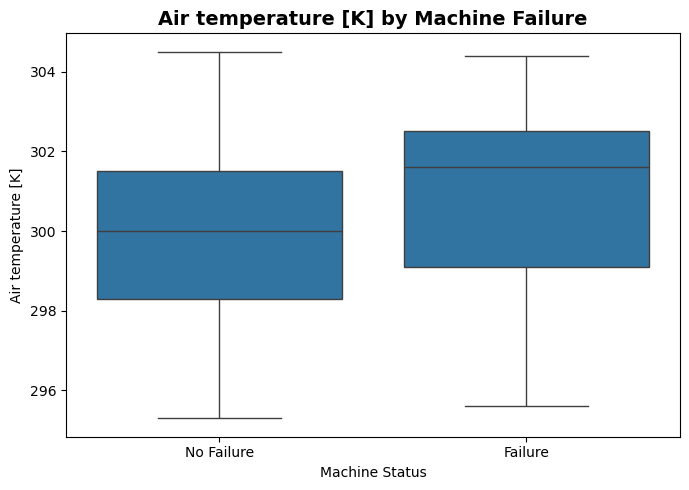

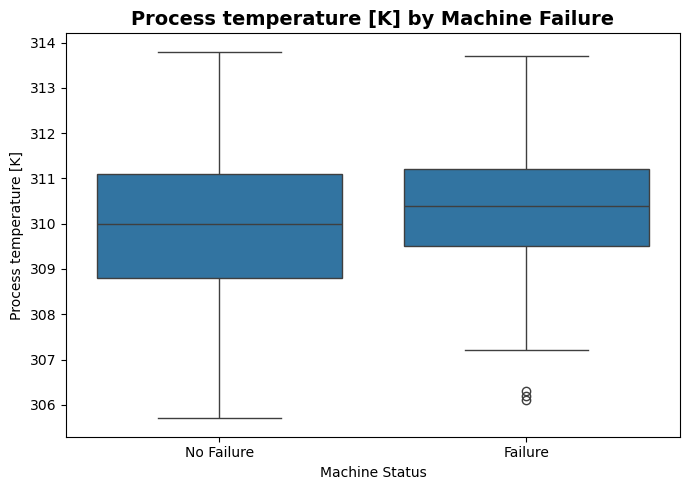

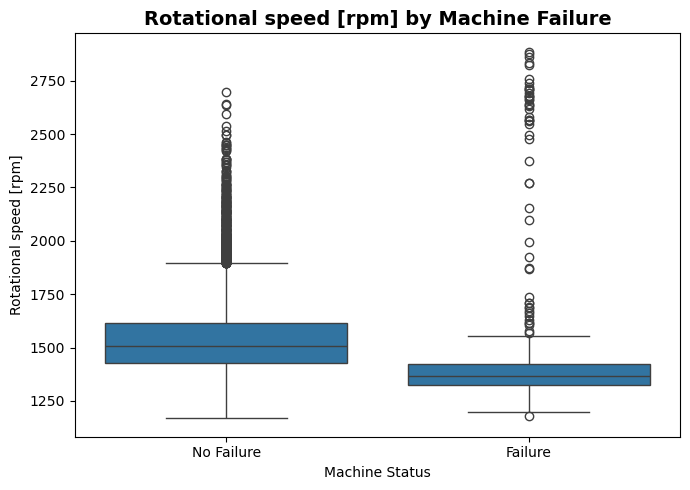

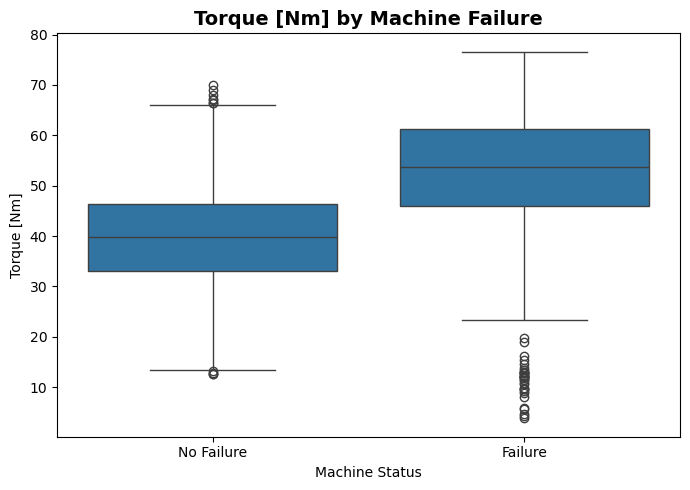

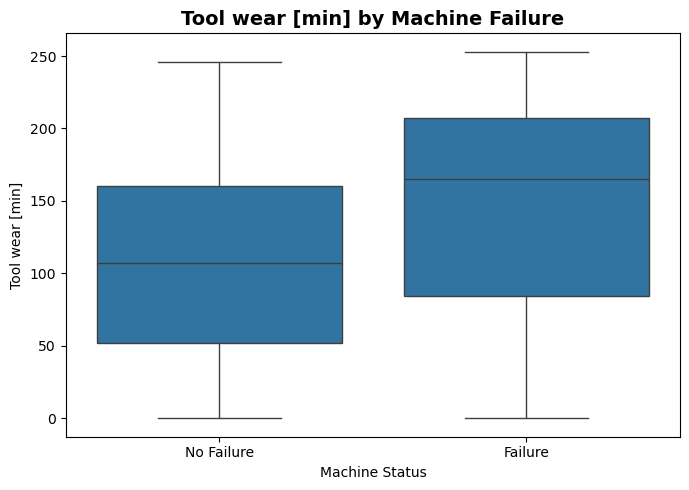

In [337]:
plot_boxplot("Air temperature [K]")
plot_boxplot("Process temperature [K]")
plot_boxplot("Rotational speed [rpm]")
plot_boxplot("Torque [Nm]")
plot_boxplot("Tool wear [min]")

In [338]:
df["Air temperature [K]"].describe()

count    10000.000000
mean       300.004930
std          2.000259
min        295.300000
25%        298.300000
50%        300.100000
75%        301.500000
max        304.500000
Name: Air temperature [K], dtype: float64

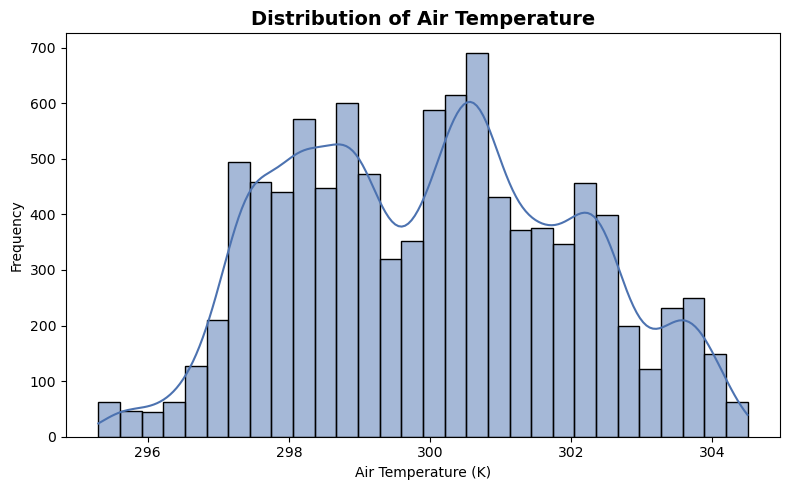

In [339]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Air temperature [K]",
    bins=30,
    kde=True,
    color="#4C72B0"
)

plt.title(
    "Distribution of Air Temperature",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Air Temperature (K)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [340]:
df["Process temperature [K]"].describe()

count    10000.000000
mean       310.005560
std          1.483734
min        305.700000
25%        308.800000
50%        310.100000
75%        311.100000
max        313.800000
Name: Process temperature [K], dtype: float64

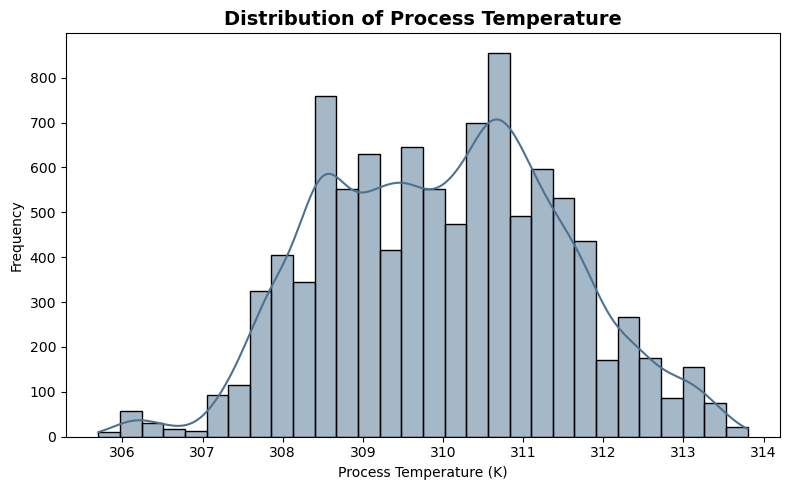

In [341]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Process temperature [K]",
    bins=30,
    kde=True,
    color="#4D7290"
)

plt.title(
    "Distribution of Process Temperature",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Process Temperature (K)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

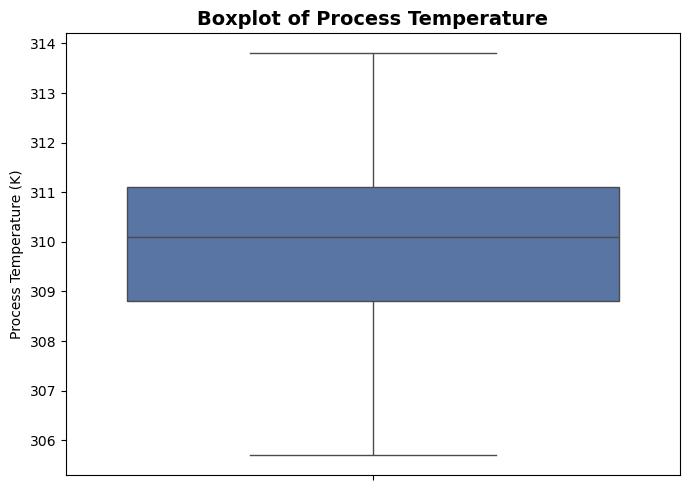

In [342]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    y="Process temperature [K]",
    color="#4C72B0"
)

plt.title(
    "Boxplot of Process Temperature",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Process Temperature (K)")

plt.tight_layout()

plt.show()

In [343]:
df["Rotational speed [rpm]"].describe()

count    10000.000000
mean      1538.776100
std        179.284096
min       1168.000000
25%       1423.000000
50%       1503.000000
75%       1612.000000
max       2886.000000
Name: Rotational speed [rpm], dtype: float64

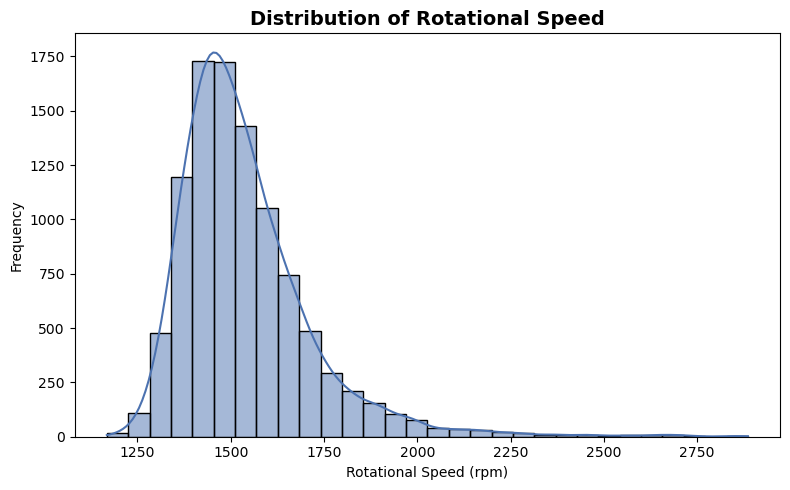

In [344]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Rotational speed [rpm]",
    bins=30,
    kde=True,
    color="#4C72B0"
)

plt.title(
    "Distribution of Rotational Speed",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

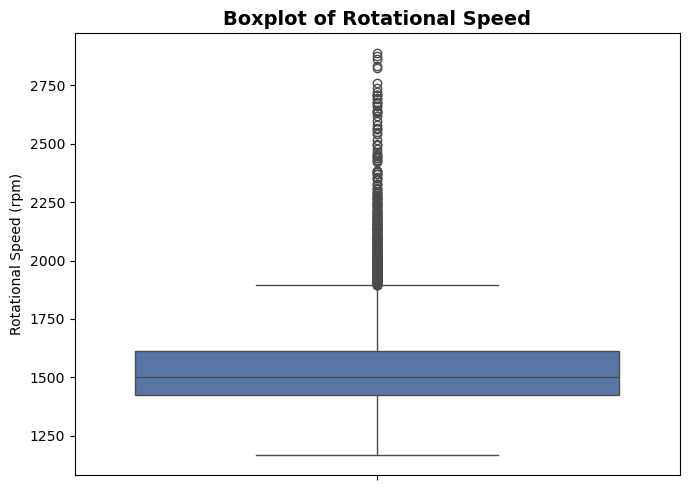

In [345]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    y="Rotational speed [rpm]",
    color="#4C72B0"
)

plt.title(
    "Boxplot of Rotational Speed",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Rotational Speed (rpm)")

plt.tight_layout()

plt.show()

In [346]:
df["Torque [Nm]"].describe()

count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: Torque [Nm], dtype: float64

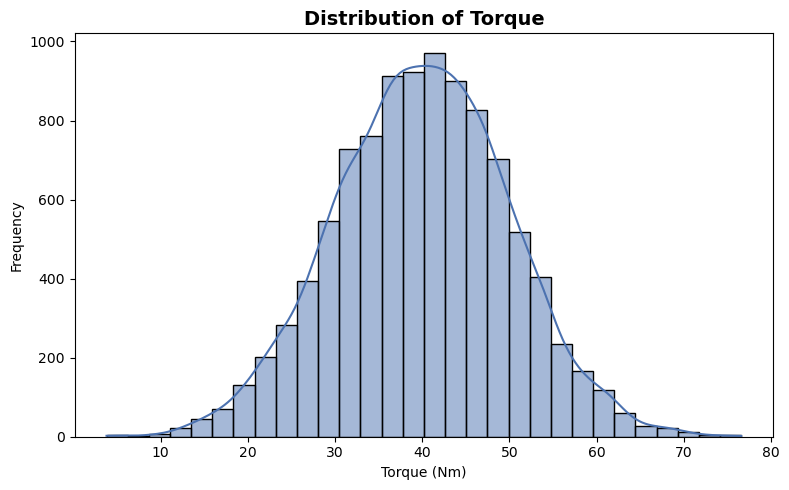

In [347]:
# Distribution of Torque

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Torque [Nm]",
    bins=30,
    kde=True,
    color="#4C72B0"
)

plt.title(
    "Distribution of Torque",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Torque (Nm)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

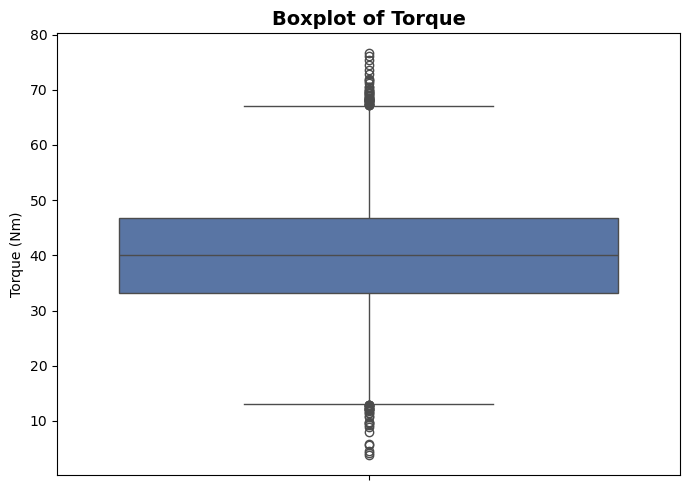

In [348]:
plt.figure(figsize=(7,5))

sns.boxplot(
    y=df["Torque [Nm]"],
    color="#4C72B0"
)

plt.title(
    "Boxplot of Torque",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Torque (Nm)")

plt.tight_layout()

plt.show()

In [349]:
df["Tool wear [min]"].describe()

count    10000.000000
mean       107.951000
std         63.654147
min          0.000000
25%         53.000000
50%        108.000000
75%        162.000000
max        253.000000
Name: Tool wear [min], dtype: float64

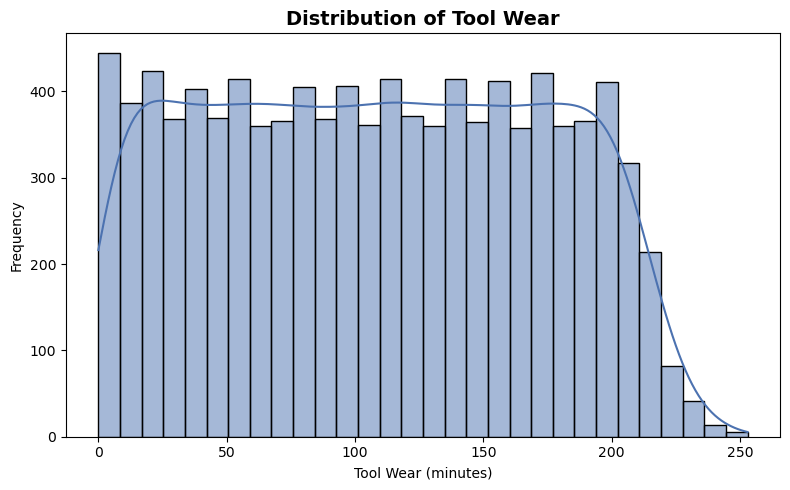

In [350]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tool wear [min]",
    bins=30,
    kde=True,
    color="#4C72B0"
)

plt.title(
    "Distribution of Tool Wear",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tool Wear (minutes)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

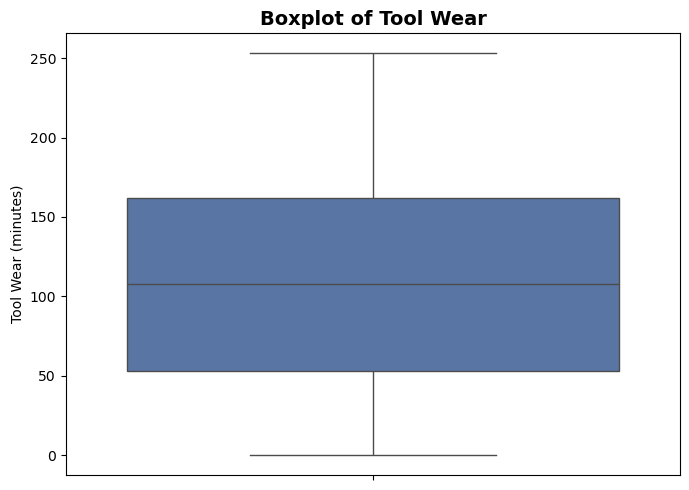

In [351]:
plt.figure(figsize=(7,5))

sns.boxplot(
    y=df["Tool wear [min]"],
    color="#4C72B0"
)

plt.title(
    "Boxplot of Tool Wear",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Tool Wear (minutes)")

plt.tight_layout()

plt.show()

<Axes: xlabel='Machine failure', ylabel='Air temperature [K]'>

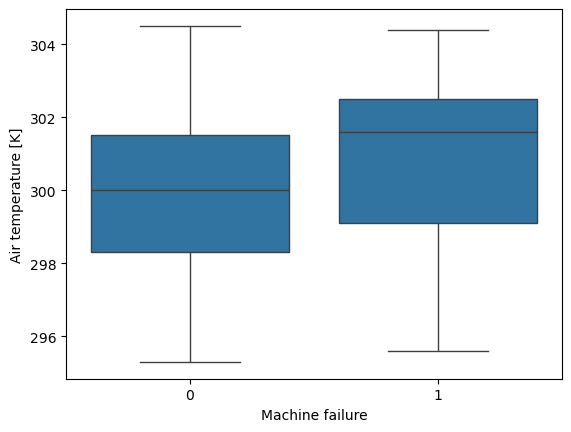

In [352]:
sns.boxplot(
    data=df,
    x="Machine failure",
    y="Air temperature [K]"
)

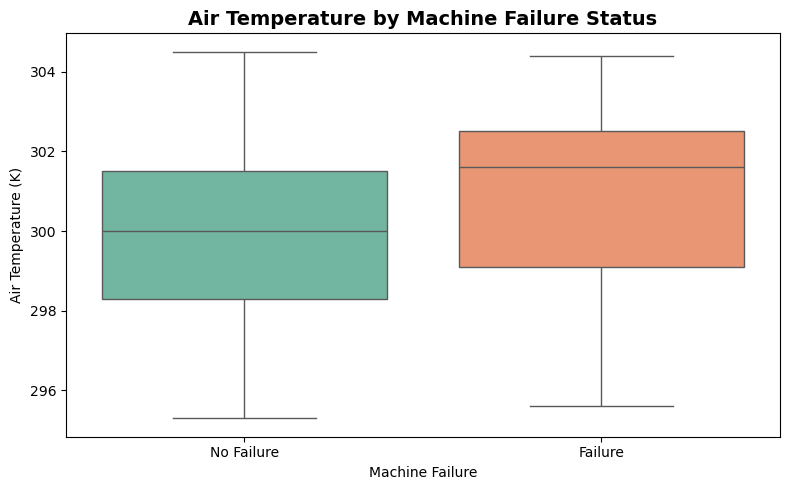

In [353]:
plt.figure(figsize=(8,5))

sns.boxplot(
data=df,
x="Machine failure",
y="Air temperature [K]",
hue="Machine failure",
palette="Set2",
legend=False

)

plt.title(
    "Air Temperature by Machine Failure Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Machine Failure")
plt.ylabel("Air Temperature (K)")

plt.xticks(
    [0,1],
    ["No Failure","Failure"]
)

plt.tight_layout()

plt.show()

In [354]:
df.groupby("Machine failure")["Air temperature [K]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,299.973999,1.990748,295.3,298.3,300.0,301.5,304.5
1,339.0,300.886431,2.071473,295.6,299.1,301.6,302.5,304.4


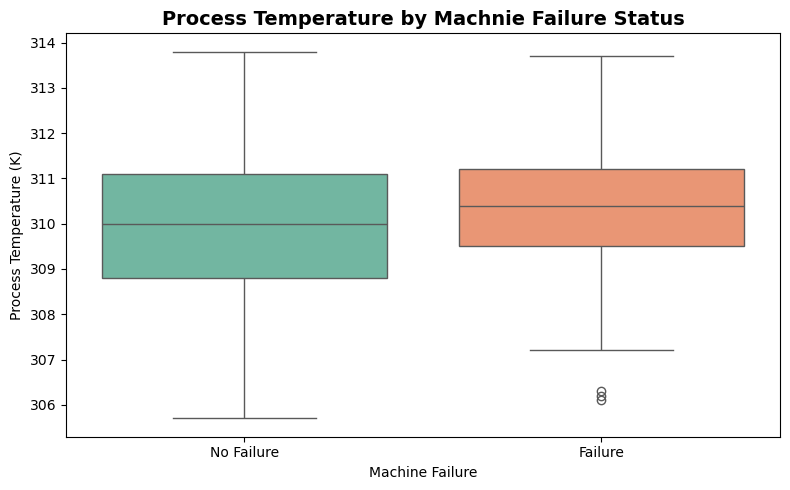

In [355]:
plt.figure(figsize=(8,5))

sns.boxplot(
data=df,
x="Machine failure",
y="Process temperature [K]",
hue="Machine failure",
palette="Set2",
legend=False
)

plt.title(
    "Process Temperature by Machnie Failure Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Machine Failure")
plt.ylabel("Process Temperature (K)")

plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.tight_layout()
plt.show()

In [356]:
df.groupby("Machine failure")["Process temperature [K]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,309.995570,1.486846,305.7,308.8,310.0,311.1,313.8
1,339.0,310.290265,1.363686,306.1,309.5,310.4,311.2,313.7


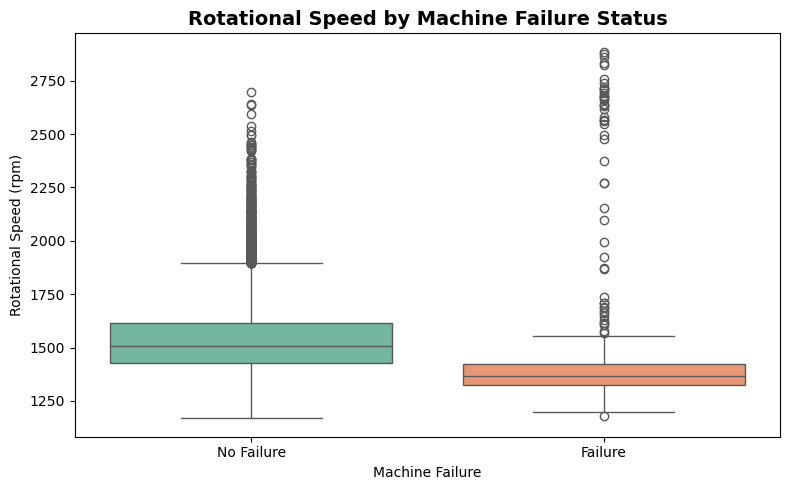

In [357]:
plt.figure(figsize=(8,5))

sns.boxplot(
data=df,
x="Machine failure",
y="Rotational speed [rpm]",
hue="Machine failure",
palette="Set2",
legend=False
)

plt.title(
    "Rotational Speed by Machine Failure Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Machine Failure")
plt.ylabel("Rotational Speed (rpm)")

plt.xticks(
    [0,1],
    ["No Failure","Failure"]
)

plt.tight_layout()

plt.show()

In [358]:
df.groupby("Machine failure")["Rotational speed [rpm]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,1540.260014,167.394734,1168.0,1429.0,1507.0,1615.0,2695.0
1,339.0,1496.486726,384.943547,1181.0,1326.5,1365.0,1421.5,2886.0


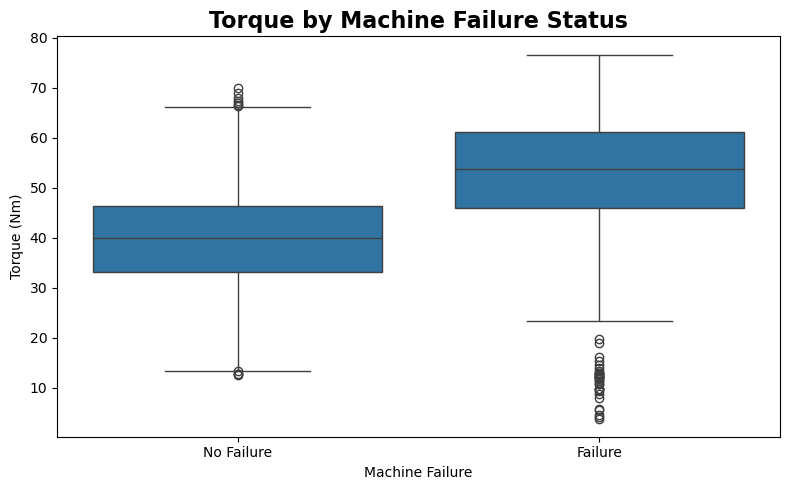

In [359]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Torque [Nm]"
)

plt.xticks([0,1], ["No Failure", "Failure"])

plt.title(
    "Torque by Machine Failure Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Failure")
plt.ylabel("Torque (Nm)")

plt.tight_layout()
plt.show()

In [360]:
df.groupby("Machine failure")["Torque [Nm]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,39.629655,9.472080,12.6,33.10,39.9,46.3,70.0
1,339.0,50.168142,16.374498,3.8,45.95,53.7,61.2,76.6


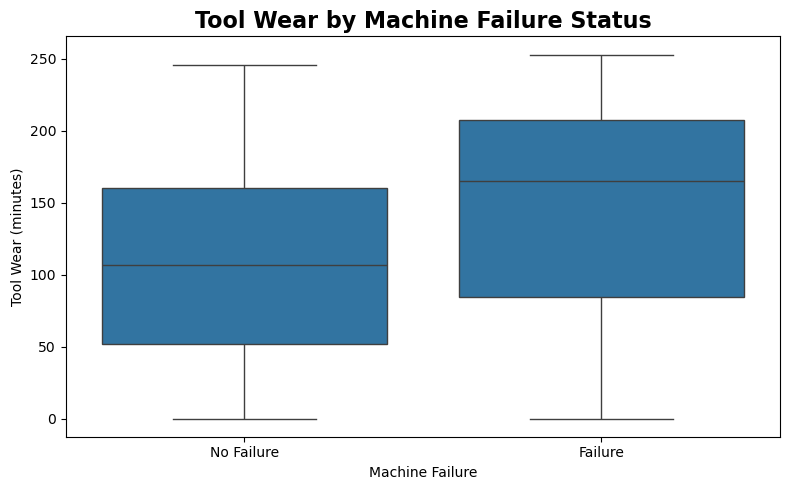

In [361]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Tool wear [min]"
)

plt.xticks([0,1], ["No Failure", "Failure"])

plt.title(
    "Tool Wear by Machine Failure Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Failure")
plt.ylabel("Tool Wear (minutes)")

plt.tight_layout()

plt.show()

In [362]:
df.groupby("Machine failure")["Tool wear [min]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,106.693717,62.945790,0.0,52.0,107.0,160.0,246.0
1,339.0,143.781711,72.759876,0.0,84.5,165.0,207.5,253.0


In [363]:
numerical_df = df[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]]

In [364]:
corr_matrix = numerical_df.corr()

corr_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


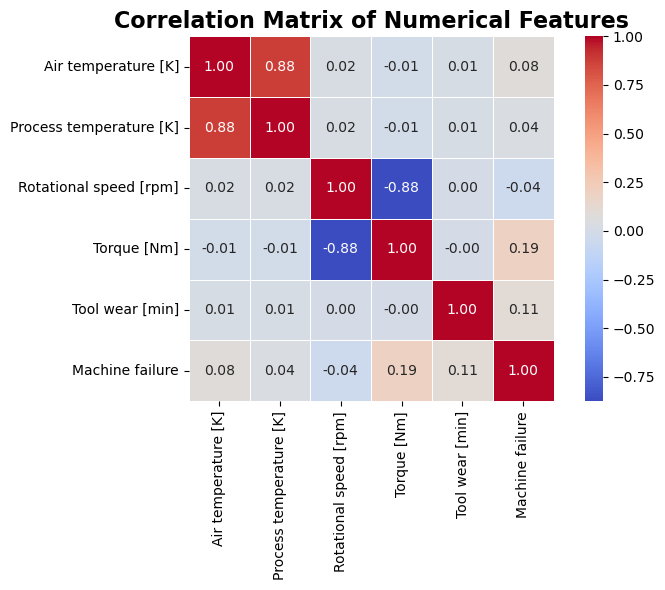

In [365]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [366]:
df = pd.read_csv(r"D:/vivian/ai4i2020.csv")


In [367]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [368]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [369]:
df_model = df.drop(columns=["UDI", "Product ID"]).copy()

In [370]:
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [371]:
print(df_model.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [372]:
pd.get_dummies(df, columns=["Type"])

,UDI,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
0,1,M14860,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,False,True
1,2,L47181,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,False,True,False
2,3,L47182,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,False,True,False
3,4,L47183,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,False,True,False
4,5,L47184,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,False,False,True
9996,9997,H39410,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,True,False,False
9997,9998,M24857,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,False,False,True
9998,9999,H39412,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,True,False,False


In [373]:
# Create a clean modelling dataframe from the original dataset
df_model = df.copy()

# Remove identifier columns
df_model = df_model.drop(
    columns=["UDI", "Product ID"]
)

# Make L the reference category
df_model["Type"] = pd.Categorical(
    df_model["Type"],
    categories=["L", "M", "H"],
    ordered=False
)

# One-hot encode Type
df_model = pd.get_dummies(
    df_model,
    columns=["Type"],
    drop_first=True,
    dtype=int
)

df_model.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_M,Type_H
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,1,0
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0,0


In [374]:
# Create a clean modelling dataframe from the original dataset
df_model = df.copy()

# Remove identifier columns
df_model = df_model.drop(
    columns=["UDI", "Product ID"]
)

# Make L the reference category
df_model["Type"] = pd.Categorical(
    df_model["Type"],
    categories=["L", "M", "H"],
    ordered=False
)

# One-hot encode Type
df_model = pd.get_dummies(
    df_model,
    columns=["Type"],
    drop_first=True,
    dtype=int
)

df_model.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_M,Type_H
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,1,0
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0,0


In [375]:
df_model.columns.tolist()

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF',
 'Type_M',
 'Type_H']

In [376]:
X = df_model.drop(columns=[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df_model["Machine failure"]

In [377]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (10000, 7)
y shape: (10000,)

Features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_M', 'Type_H']

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [378]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [379]:
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (8000, 7)
Testing feature shape: (2000, 7)

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [380]:
from imblearn.over_sampling import SMOTE

In [381]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [382]:
# Apply SMOTE only to the training data
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [383]:
print("Original training set:")
print(y_train.value_counts())

print("\nBalanced training set:")
print(y_train_smote.value_counts())

print("\nBalanced feature shape:")
print(X_train_smote.shape)

Original training set:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Balanced training set:
Machine failure
0    7729
1    7729
Name: count, dtype: int64

Balanced feature shape:
(15458, 7)


In [384]:
from sklearn.preprocessing import StandardScaler

In [385]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [386]:
scaler = StandardScaler()

In [387]:
X_train_lr = X_train_smote.copy()

X_train_lr[numeric_features] = scaler.fit_transform(
    X_train_smote[numeric_features]
)

In [388]:
X_test_lr = X_test.copy()

X_test_lr[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

In [389]:
print(X_train_lr.head())

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0             0.788889                 0.548215               -0.214936   
1            -1.792396                -1.414415               -0.405185   
2             0.272632                 1.076615               -0.545369   
3            -0.811508                -0.282128               -0.365133   
4            -1.740771                -1.263443                0.709606   

   Torque [Nm]  Tool wear [min]  Type_M  Type_H  
0     0.167420        -0.988097       1       0  
1     0.110965         0.114279       1       0  
2     0.054509         0.184944       1       0  
3     0.809599        -0.564106       0       0  
4    -1.138110        -1.044629       0       0  


In [390]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

In [391]:
# Create Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
lr_model.fit(
    X_train_lr,
    y_train_smote
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [392]:
# Predict class labels
y_pred_lr = lr_model.predict(X_test_lr)

# Predict probabilities
y_prob_lr = lr_model.predict_proba(X_test_lr)[:, 1]

In [393]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.8555
Precision: 0.1557632398753894
Recall   : 0.7352941176470589
F1 Score : 0.2570694087403599
ROC AUC  : 0.8835479844111558


In [394]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1932
           1       0.16      0.74      0.26        68

    accuracy                           0.86      2000
   macro avg       0.57      0.80      0.59      2000
weighted avg       0.96      0.86      0.90      2000



In [395]:
from sklearn.ensemble import RandomForestClassifier

In [396]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [397]:
rf_model.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [398]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [399]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.959
Precision: 0.43636363636363634
Recall   : 0.7058823529411765
F1 Score : 0.5393258426966292
ROC AUC  : 0.9640078857630008


In [400]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.44      0.71      0.54        68

    accuracy                           0.96      2000
   macro avg       0.71      0.84      0.76      2000
weighted avg       0.97      0.96      0.96      2000



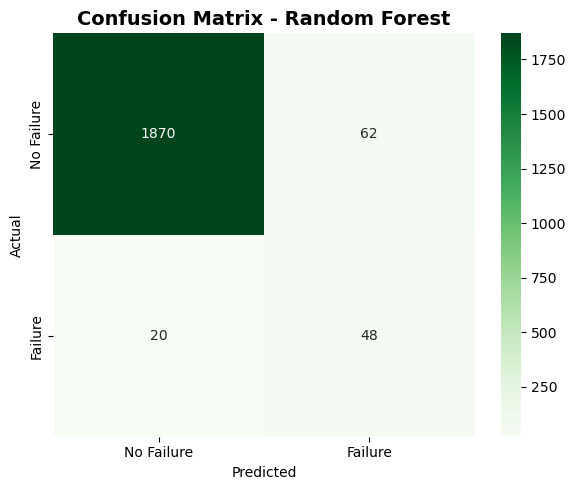

In [401]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Failure","Failure"],
    yticklabels=["No Failure","Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

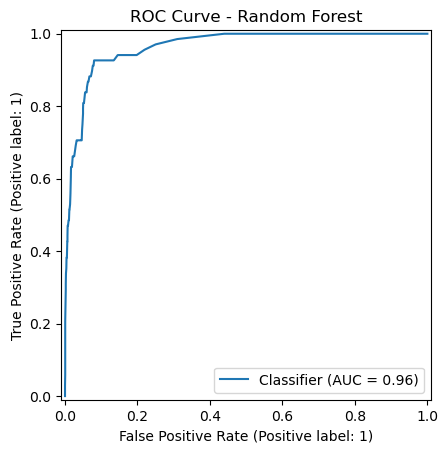

In [402]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title(
    "ROC Curve - Random Forest"
)

plt.show()

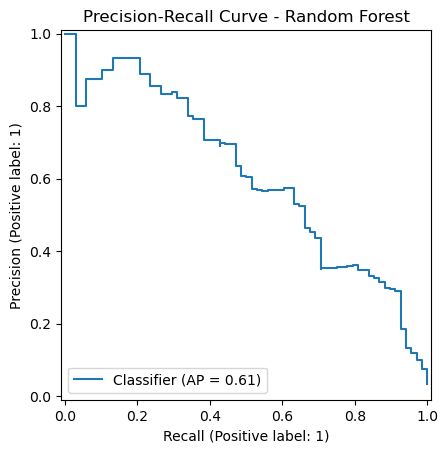

In [403]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title(
    "Precision-Recall Curve - Random Forest"
)

plt.show()

In [404]:
!pip install xgboost

In [405]:
from xgboost import XGBClassifier

In [406]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [407]:
# Create XGBoost-specific copies with safe column names
X_train_xgb = X_train_smote.copy()
X_test_xgb = X_test.copy()

# Clean feature names
X_train_xgb.columns = (
    X_train_xgb.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(" ", "_", regex=False)
)

X_test_xgb.columns = X_train_xgb.columns

In [408]:
print(X_train_xgb.columns.tolist())

['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_M', 'Type_H']


In [409]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_xgb,
    y_train_smote
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [410]:
y_pred_xgb = xgb_model.predict(X_test_xgb)

y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

In [411]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.9585
Precision: 0.4409448818897638
Recall   : 0.8235294117647058
F1 Score : 0.5743589743589743
ROC AUC  : 0.9711971745219827


In [412]:
print(classification_report(
    y_test,
    y_pred_xgb
))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1932
           1       0.44      0.82      0.57        68

    accuracy                           0.96      2000
   macro avg       0.72      0.89      0.78      2000
weighted avg       0.97      0.96      0.96      2000



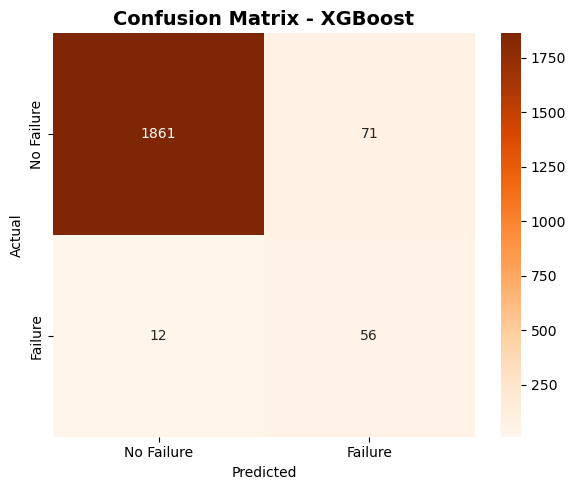

In [413]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "Confusion Matrix - XGBoost",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

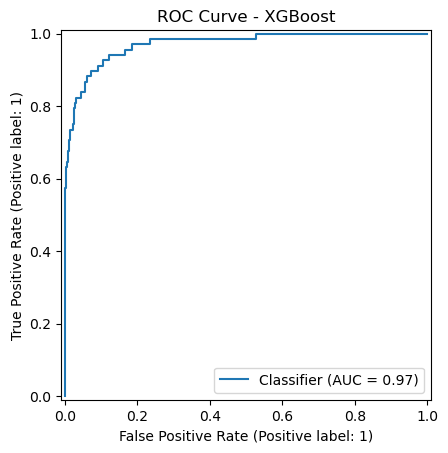

In [414]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("ROC Curve - XGBoost")
plt.show()

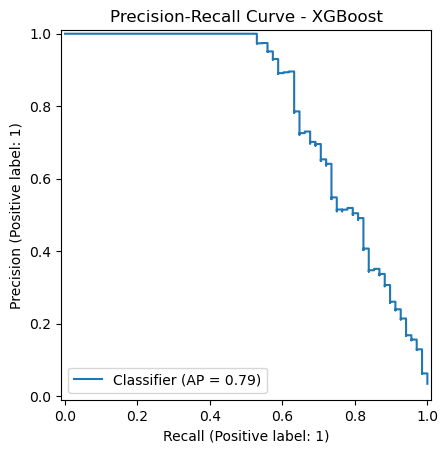

In [415]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("Precision-Recall Curve - XGBoost")
plt.show()

In [416]:
from sklearn.model_selection import StratifiedKFold, cross_validate

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [417]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [418]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

In [419]:
lr_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

lr_cv = cross_validate(
    lr_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression Cross Validation")
print("-----------------------------------")
for metric in scoring:
    print(f"{metric}: {lr_cv['test_' + metric].mean():.4f}")

Logistic Regression Cross Validation
-----------------------------------
accuracy: 0.8403
precision: 0.1457
recall: 0.7612
f1: 0.2445
roc_auc: 0.8835
average_precision: 0.3854


In [420]:
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ))
])

rf_cv = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest Cross Validation")
print("--------------------------------")

for metric in scoring:
    print(f"{metric}: {rf_cv['test_' + metric].mean():.4f}")

Random Forest Cross Validation
--------------------------------
accuracy: 0.9605
precision: 0.4524
recall: 0.7318
f1: 0.5582
roc_auc: 0.9629
average_precision: 0.6491


In [421]:
X_xgb = X.copy()

X_xgb.columns = (
    X_xgb.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(" ", "_", regex=False)
)

print(X_xgb.columns.tolist())

['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_M', 'Type_H']


In [422]:
xgb_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_cv = cross_validate(
    xgb_pipeline,
    X_xgb,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("XGBoost Cross Validation")
print("-------------------------")

for metric in scoring:
    print(f"{metric}: {xgb_cv['test_' + metric].mean():.4f}")

XGBoost Cross Validation
-------------------------
accuracy: 0.9590
precision: 0.4474
recall: 0.8290
f1: 0.5797
roc_auc: 0.9670
average_precision: 0.7499


In [423]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_tuning_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter search space
rf_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}


In [424]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [425]:
rf_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [426]:
print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validation Average Precision:")
print(round(rf_random_search.best_score_, 4))

Best Random Forest Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 30}

Best Cross-Validation Average Precision:
0.6416


In [427]:
best_rf = rf_random_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

In [428]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Tuned Random Forest")
print("-------------------")
print("Accuracy          :", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision         :", precision_score(y_test, y_pred_rf_tuned))
print("Recall            :", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score          :", f1_score(y_test, y_pred_rf_tuned))
print("ROC AUC           :", roc_auc_score(y_test, y_prob_rf_tuned))
print("Average Precision :", average_precision_score(y_test, y_prob_rf_tuned))

Tuned Random Forest
-------------------
Accuracy          : 0.951
Precision         : 0.3897058823529412
Recall            : 0.7794117647058824
F1 Score          : 0.5196078431372549
ROC AUC           : 0.9644151138716357
Average Precision : 0.5974604361435001


In [429]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

xgb_tuning_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [430]:
xgb_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

In [431]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [432]:
# Clean feature names for the ORIGINAL training set
X_train_xgb_cv = X_train.copy()

X_train_xgb_cv.columns = (
    X_train_xgb_cv.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(" ", "_", regex=False)
)

print("X_train_xgb_cv shape:", X_train_xgb_cv.shape)
print("y_train shape:", y_train.shape)

print(X_train_xgb_cv.columns.tolist())

X_train_xgb_cv shape: (8000, 7)
y_train shape: (8000,)
['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_M', 'Type_H']


In [433]:
xgb_random_search.fit(
    X_train_xgb_cv,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.8, 0.9, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [434]:
y_train

4058    0
1221    0
6895    0
9863    0
8711    0
       ..
980     0
4266    0
7772    0
5780    0
1424    0
Name: Machine failure, Length: 8000, dtype: int64

In [435]:
print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

print("\nBest Cross-Validation Average Precision:")
print(round(xgb_random_search.best_score_, 4))

Best XGBoost Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 1.0}

Best Cross-Validation Average Precision:
0.7356


In [436]:
best_xgb = xgb_random_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test_xgb)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test_xgb)[:, 1]

In [437]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Tuned XGBoost")
print("----------------")

print("Accuracy          :", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision         :", precision_score(y_test, y_pred_xgb_tuned))
print("Recall            :", recall_score(y_test, y_pred_xgb_tuned))
print("F1 Score          :", f1_score(y_test, y_pred_xgb_tuned))
print("ROC AUC           :", roc_auc_score(y_test, y_prob_xgb_tuned))
print("Average Precision :", average_precision_score(y_test, y_prob_xgb_tuned))

Tuned XGBoost
----------------
Accuracy          : 0.968
Precision         : 0.5188679245283019
Recall            : 0.8088235294117647
F1 Score          : 0.632183908045977
ROC AUC           : 0.9700249665083425
Average Precision : 0.7714901612726551


In [438]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract the trained XGBoost model from the pipeline
xgb_model_final = best_xgb.named_steps["model"]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train_xgb_cv.columns,
    "Importance": xgb_model_final.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Rotational_speed_rpm,0.211102
3,Torque_Nm,0.208903
5,Type_M,0.203037
6,Type_H,0.166143
4,Tool_wear_min,0.132864
0,Air_temperature_K,0.041792
1,Process_temperature_K,0.036159


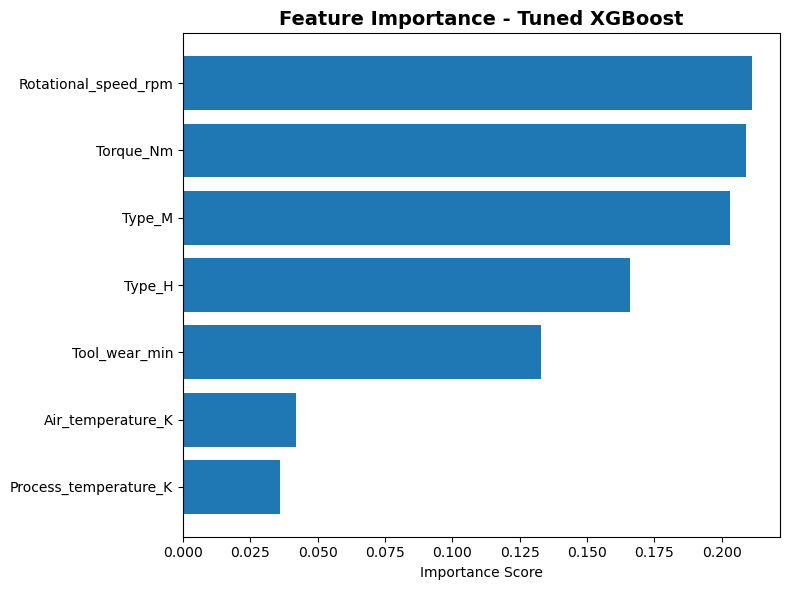

In [439]:
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Feature Importance - Tuned XGBoost",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

In [440]:
import shap

# Initialize JavaScript visualization
shap.initjs()

In [441]:
best_xgb = xgb_random_search.best_estimator_.named_steps["model"]

explainer = shap.TreeExplainer(best_xgb)

In [442]:
shap_values = explainer.shap_values(X_test_xgb)

In [443]:
print(shap_values.shape)
print(X_test_xgb.shape)

(2000, 7)
(2000, 7)


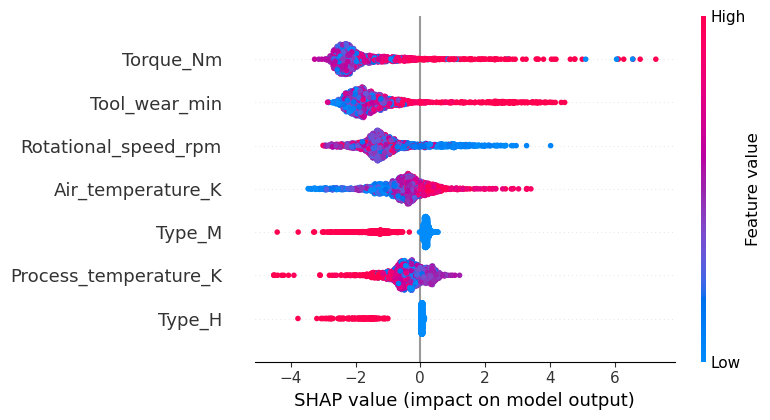

In [444]:
shap.summary_plot(
    shap_values,
    X_test_xgb,
    feature_names=X_test_xgb.columns
)

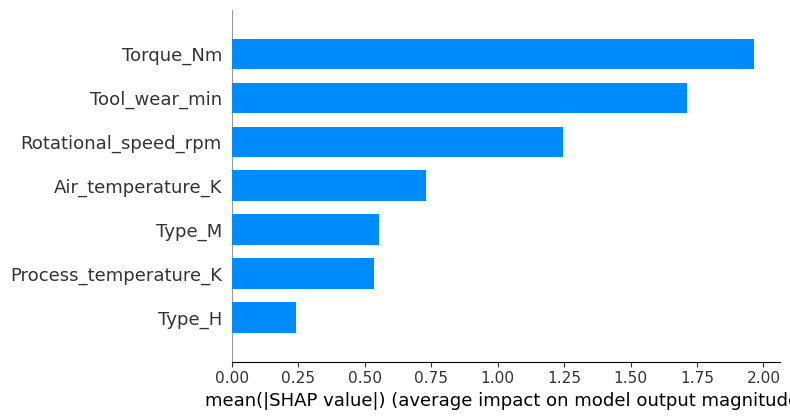

In [445]:
shap.summary_plot(
    shap_values,
    X_test_xgb,
    feature_names=X_test_xgb.columns,
    plot_type="bar"
)

In [446]:
instance = 0

In [447]:
shap_values_single = explainer(X_test_xgb.iloc[[instance]])

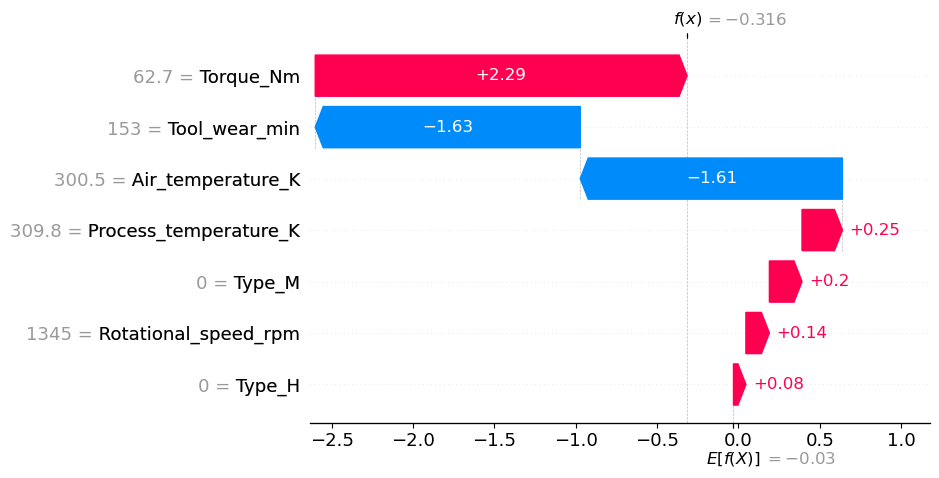

In [448]:
shap.plots.waterfall(shap_values_single[0])

In [449]:
shap.initjs()

shap.plots.force(shap_values_single[0])

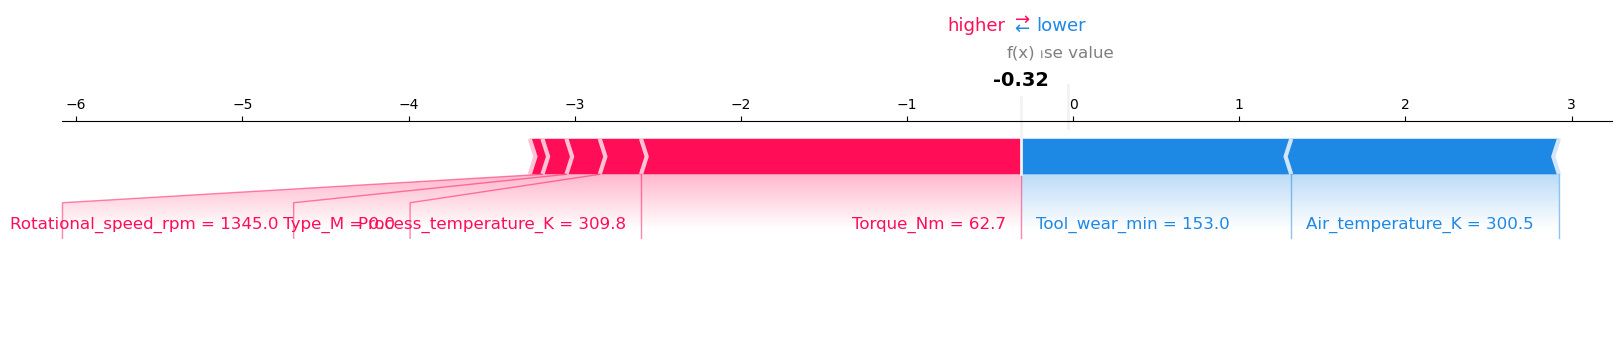

In [450]:
shap.force_plot(
    explainer.expected_value,
    shap_values[instance],
    X_test_xgb.iloc[instance],
    matplotlib=True
)

In [451]:
failed_index = y_test[y_test == 1].index[0]

failed_row = X_test_xgb.loc[[failed_index]]

failed_row

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_M,Type_H
4851,303.7,312.1,1363,51.8,90,0,0


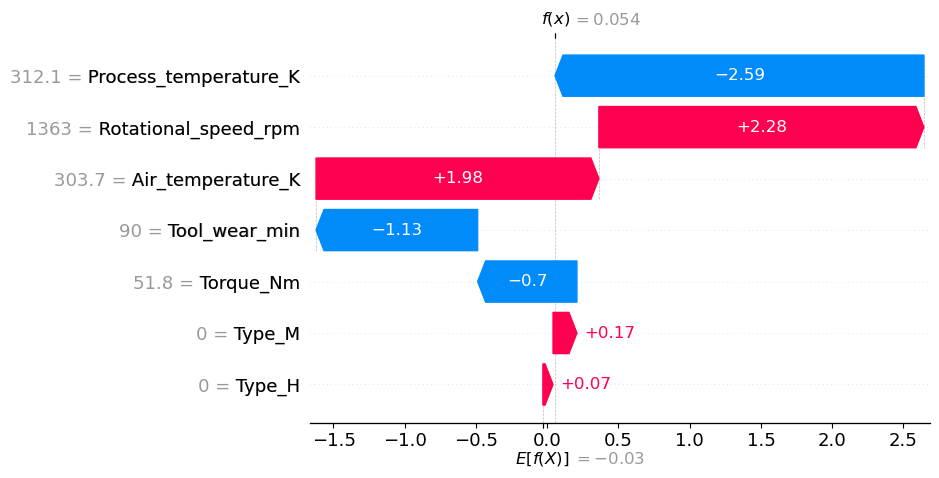

In [452]:
failed_shap = explainer(failed_row)

shap.plots.waterfall(failed_shap[0])

In [453]:
# Full tuned XGBoost pipeline: SMOTE + XGBoost
best_xgb_pipeline = xgb_random_search.best_estimator_

print(type(best_xgb_pipeline))

<class 'imblearn.pipeline.Pipeline'>


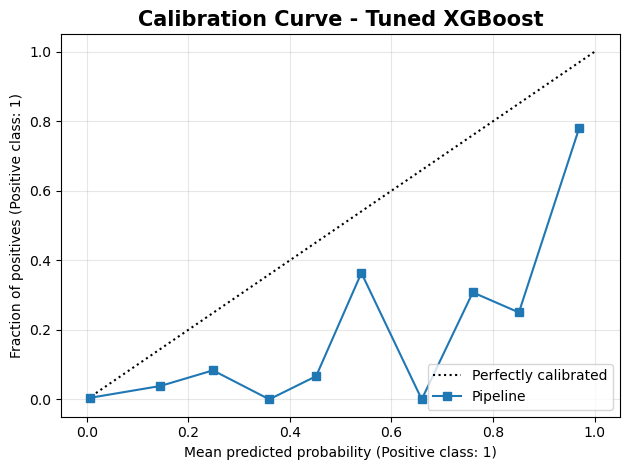

In [454]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

CalibrationDisplay.from_estimator(
    best_xgb_pipeline,
    X_test_xgb,
    y_test,
    n_bins=10,
    strategy="uniform"
)

plt.title(
    "Calibration Curve - Tuned XGBoost",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [455]:
from sklearn.metrics import brier_score_loss

y_prob_cal = best_xgb_pipeline.predict_proba(X_test_xgb)[:, 1]

brier = brier_score_loss(
    y_test,
    y_prob_cal
)

print("Model Brier Score:", round(brier,4))

Model Brier Score: 0.0253


In [456]:
failure_prevalence = y_test.mean()

baseline_prob = np.repeat(
    failure_prevalence,
    len(y_test)
)

baseline_brier = brier_score_loss(
    y_test,
    baseline_prob
)

print("Model Brier Score   :", round(brier,4))
print("Baseline Brier Score:", round(baseline_brier,4))

Model Brier Score   : 0.0253
Baseline Brier Score: 0.0328


In [457]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Predicted probabilities
y_prob = best_xgb_pipeline.predict_proba(X_test_xgb)[:, 1]

# Precision–Recall curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

# Compute F1 score for every threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
) / (
    precision[:-1] + recall[:-1] + 1e-10
)

# Best threshold
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold :", round(best_threshold, 3))
print("Best F1 Score  :", round(f1_scores[best_index], 3))

Best Threshold : 0.925
Best F1 Score  : 0.723


In [458]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# New predictions
y_pred_best = (
    y_prob >= best_threshold
).astype(int)

print(classification_report(
    y_test,
    y_pred_best
))

print(confusion_matrix(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.84      0.63      0.72        68

    accuracy                           0.98      2000
   macro avg       0.92      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000

[[1924    8]
 [  25   43]]


In [459]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [460]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

In [461]:
rf_correct = (y_pred_rf_tuned == y_test)
xgb_correct = (y_pred_xgb_tuned == y_test)

table = np.zeros((2, 2), dtype=int)

table[0, 0] = np.sum((rf_correct == True) & (xgb_correct == True))
table[0, 1] = np.sum((rf_correct == True) & (xgb_correct == False))
table[1, 0] = np.sum((rf_correct == False) & (xgb_correct == True))
table[1, 1] = np.sum((rf_correct == False) & (xgb_correct == False))

print(table)

[[1897    5]
 [  39   59]]


In [462]:
result = mcnemar(
    table,
    exact=False,
    correction=True
)

print("Statistic :", round(result.statistic, 4))
print("p-value   :", result.pvalue)

Statistic : 24.75
p-value   : 6.526880098391141e-07


In [463]:
alpha = 0.05

if result.pvalue < alpha:
    print("Statistically significant difference.")
else:
    print("No statistically significant difference.")

Statistically significant difference.


In [464]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_ablation(features_to_drop, experiment_name):

    X_train_ab = X_train.drop(columns=features_to_drop)
    X_test_ab = X_test.drop(columns=features_to_drop)

    model = xgb_random_search.best_estimator_

    model.fit(X_train_ab, y_train)

    y_pred = model.predict(X_test_ab)
    y_prob = model.predict_proba(X_test_ab)[:,1]

    return {
        "Experiment": experiment_name,
        "Removed Features": ", ".join(features_to_drop) if features_to_drop else "None",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

In [465]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_ablation(features_to_drop, experiment_name):

    # Use XGBoost-safe feature names
    X_train_ab = X_train_xgb_cv.drop(columns=features_to_drop)
    X_test_ab = X_test_xgb.drop(columns=features_to_drop)

    # Clone the tuned pipeline
    model = clone(best_xgb_pipeline)

    model.fit(X_train_ab, y_train)

    y_pred = model.predict(X_test_ab)
    y_prob = model.predict_proba(X_test_ab)[:,1]

    return {
        "Experiment": experiment_name,
        "Removed Features": ", ".join(features_to_drop) if features_to_drop else "None",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

In [466]:
results = []

results.append(evaluate_ablation([], "Full Model"))

results.append(
    evaluate_ablation(
        ["Type_M","Type_H"],
        "Without Machine Type"
    )
)

results.append(
    evaluate_ablation(
        ["Tool_wear_min"],
        "Without Tool Wear"
    )
)

results.append(
    evaluate_ablation(
        ["Air_temperature_K","Process_temperature_K"],
        "Without Temperatures"
    )
)

results.append(
    evaluate_ablation(
        ["Rotational_speed_rpm"],
        "Without Rotational Speed"
    )
)

results.append(
    evaluate_ablation(
        ["Torque_Nm"],
        "Without Torque"
    )
)

ablation_results = pd.DataFrame(results).round(4)

ablation_results

,Experiment,Removed Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Full Model,None,0.9680,0.5189,0.8088,0.6322,0.9700
1,Without Machine Type,"Type_M, Type_H",0.9600,0.4500,0.7941,0.5745,0.9715
2,Without Tool Wear,Tool_wear_min,0.9600,0.4375,0.6176,0.5122,0.8470
3,Without Temperatures,"Air_temperature_K, Process_temperature_K",0.9190,0.2299,0.5882,0.3306,0.9102
4,Without Rotational Speed,Rotational_speed_rpm,0.9515,0.3802,0.6765,0.4868,0.9329
5,Without Torque,Torque_Nm,0.9485,0.3684,0.7206,0.4876,0.9266


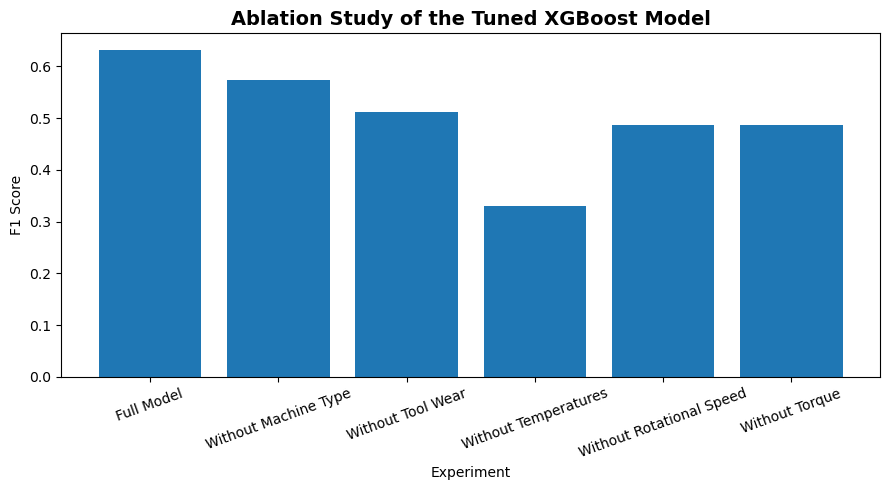

In [467]:
plt.figure(figsize=(9,5))

plt.bar(
    ablation_results["Experiment"],
    ablation_results["F1"]
)

plt.ylabel("F1 Score")
plt.xlabel("Experiment")

plt.title(
    "Ablation Study of the Tuned XGBoost Model",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [468]:
import sys
print(sys.executable)

C:\vivian\python.exe
